In [1]:
import numpy as np

from borf import BORF
from downtime import load_dataset
from lightgbm import LGBMRegressor
from sklearn.pipeline import make_pipeline
from borf.xai.borf_shap_explainer import BorfShapExplainer
import matplotlib.pyplot as plt

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
d = load_dataset("Covid3Month")
X_train, y_train, X_test, y_test = d()
print(d)

X_train: (140, 1, 84)
X_test: (61, 1, 84)
y_train: (140,)
y_test: (61,)
Metadata:
{'name': 'Covid3Month', 'task': 'regression'}


In [3]:
pipe = make_pipeline(
    BORF(
        n_jobs=1,
        min_window_to_signal_std_ratio=0.05,
        normalize_flatten_to_zero=True,
        alphabets_slope_min_symbols=0,
        alphabets_slope_max_symbols=1,
        alphabets_mean_min_symbols=3,
        alphabets_mean_max_symbols=4,
    ),
    LGBMRegressor(),
)
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008936 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2568
[LightGBM] [Info] Number of data points in the train set: 140, number of used features: 342
[LightGBM] [Info] Start training from score 0.036898
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

Converting data to scipy sparse matrix.


-0.06975397619870405

In [4]:
exp = BorfShapExplainer(transformer=pipe[0], pipeline=pipe, X_shapes_ratio=0.1)

In [5]:
%%time
exp.fit(X_train)

CPU times: user 1.35 s, sys: 181 ms, total: 1.53 s
Wall time: 1.03 s


In [15]:
i = 14
x = X_test[i : i + 1]
print("y =", y_test[i], "y_pred = ", pipe.predict(x)[0])

y = 0.0078125 $\hat{y}$ = 0.008768187248515101


Converting data to scipy sparse matrix.


In [8]:
%%time
e = exp.explain(x, explanation_type="features_shapes_saliency")[0]

Mean of empty slice.
invalid value encountered in scalar divide


CPU times: user 59.3 s, sys: 834 ms, total: 1min
Wall time: 59.2 s


In [9]:
word_importance = (
    e.word_importance[:, :, 0]
    .to_pandas()
    .T.sort_values(by="abs_shap_values", ascending=False)
)

In [10]:
word_importance

rows,feature_idxs,signal_idxs,shap_values,abs_shap_values,shap_values_length_ratio,abs_shap_values_length_ratio,counts
words,,,,,,,
"3_0_4_1_4_4;0;0,0,0,2",112.0,0.0,-0.007822,0.007822,-0.001956,0.001956,4.0
"3_0_4_1_16_4;0;1,1,1,2",4224.0,0.0,-0.005803,0.005803,-0.000363,0.000363,11.0
"3_0_2_1_8_2;0;0,2",1631.0,0.0,-0.004496,0.004496,-0.000562,0.000562,16.0
"3_0_1_1_16_2;0;1,1",3012.0,0.0,-0.003403,0.003403,-0.000213,0.000213,54.0
"3_0_2_1_4_2;0;2,0",56.0,0.0,-0.003391,0.003391,-0.000848,0.000848,6.0
...,...,...,...,...,...,...,...
"3_0_2_1_8_2;0;2,0",1632.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0
"3_0_1_1_8_8;0;0,2,0,0,0,1,2,2",1629.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0
"3_0_1_1_8_8;0;1,0,2,0,0,1,1,2",1628.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0


[<Axes: title={'center': 'word:3_0_2_1_16_4;0;1,1,2,1, signal:0, label: 0 - 0.008768187248515101\n, shap_value: -0.0, value: 0.0'}>]

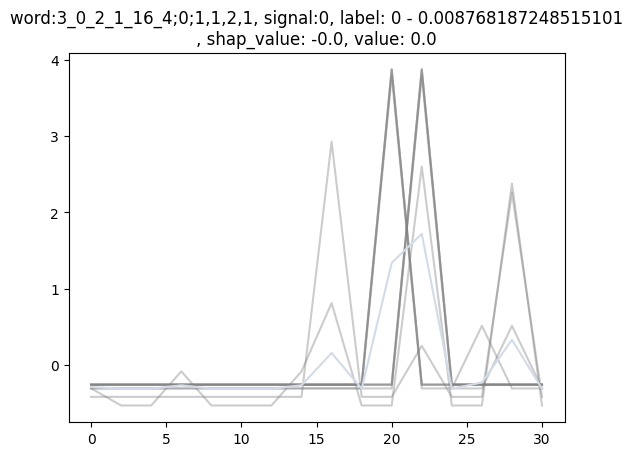

In [11]:
e.plot_words(1, not_contained_only=True)

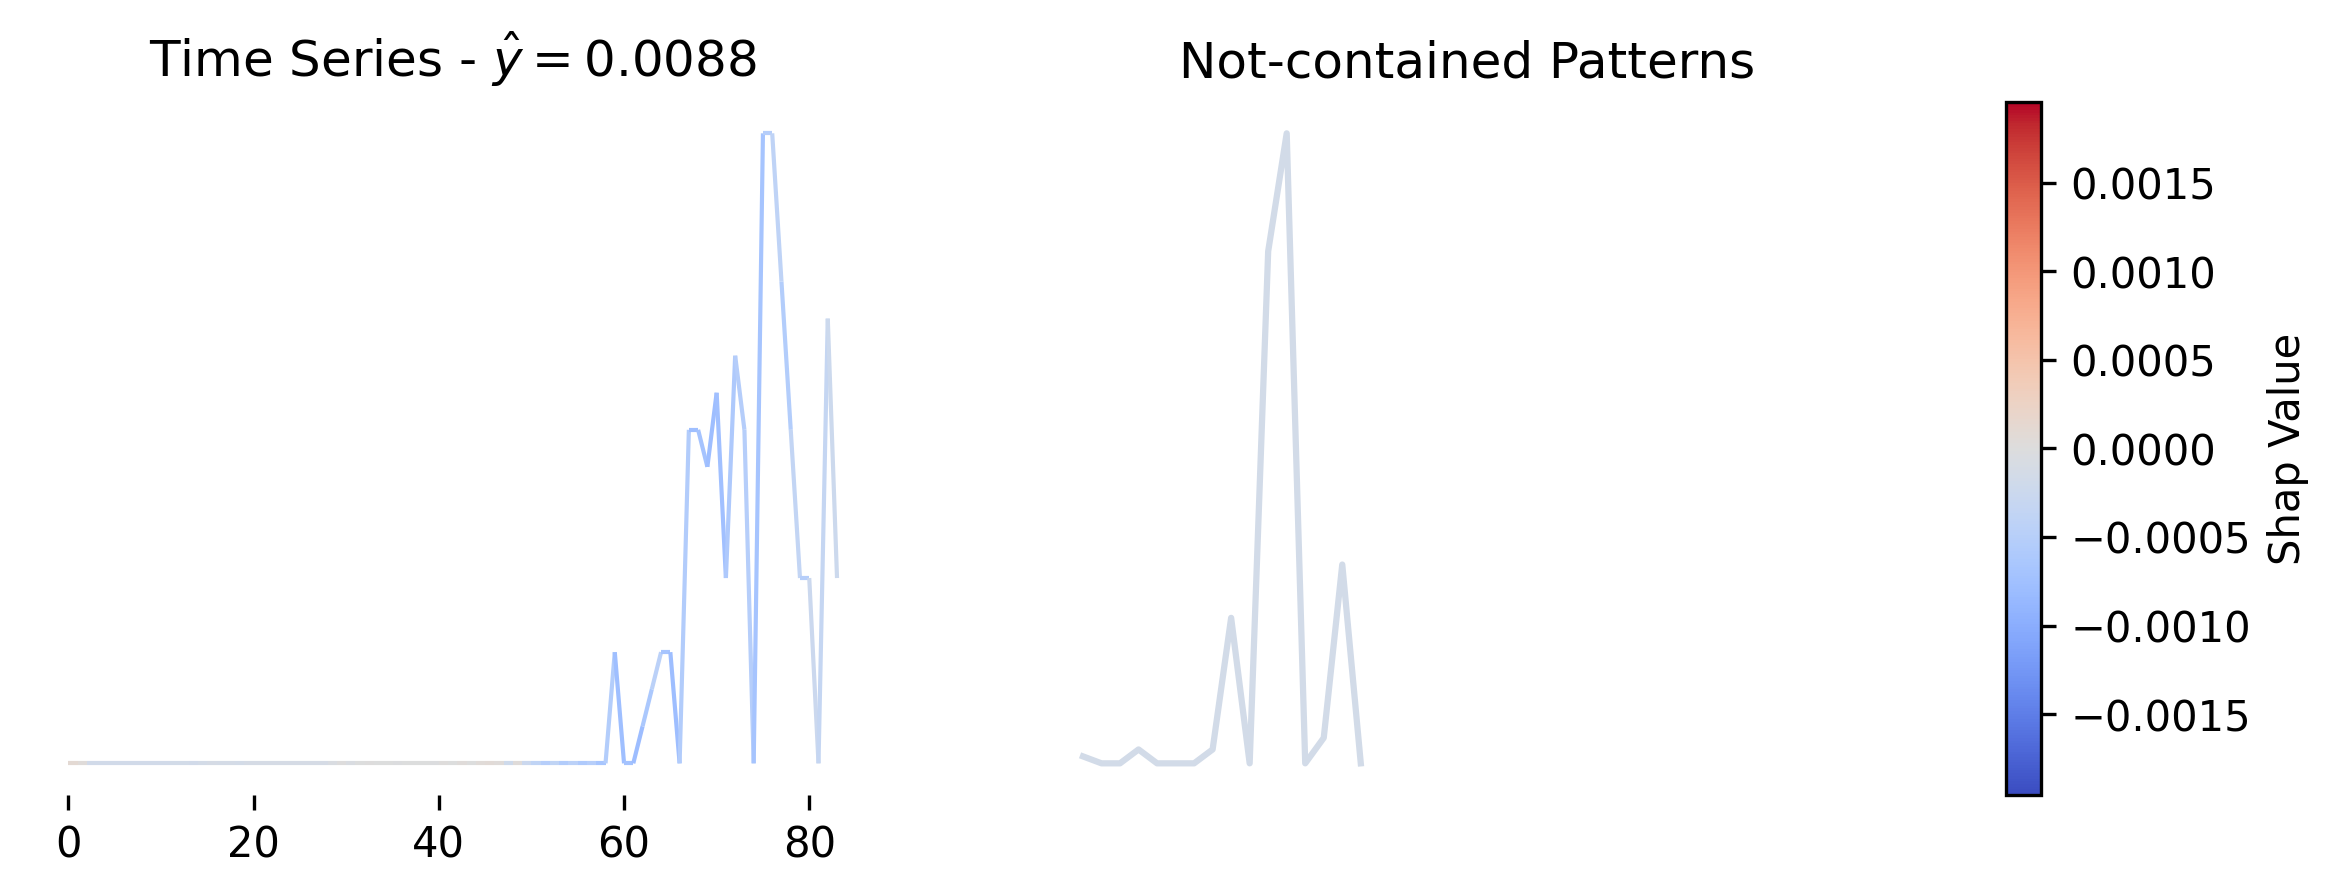

In [12]:
e.plot(figsize=(10, 3))
plt.show()

In [13]:
e.receptive_fields[2574].get_multiple_alignment_indexes(e.x)

<Array [[]] type='1 * var * unknown'>

In [14]:
print("ciao")

ciao
